In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful")

Setup successful


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_path = "/kaggle/input/competitions/shopee-product-matching/train.csv"
test_path = "/kaggle/input/competitions/shopee-product-matching/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (34250, 5)
Test shape: (3, 4)


In [9]:
train.head()
train.info()
train.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   posting_id   34250 non-null  object
 1   image        34250 non-null  object
 2   image_phash  34250 non-null  object
 3   title        34250 non-null  object
 4   label_group  34250 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


Index(['posting_id', 'image', 'image_phash', 'title', 'label_group'], dtype='object')

In [10]:
print("Number of listings:", len(train))
print("Number of unique product groups:", train["label_group"].nunique())
train.isnull().sum()

Number of listings: 34250
Number of unique product groups: 11014


posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

In [11]:
print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)

print("\nNUMBER OF LISTINGS:")
print(len(train))

print("\nUNIQUE PRODUCT GROUPS:")
print(train["label_group"].nunique())

print("\nMISSING VALUES:")
print(train.isnull().sum())

train.head()
train.info()

TRAIN SHAPE: (34250, 5)
TEST SHAPE: (3, 4)

NUMBER OF LISTINGS:
34250

UNIQUE PRODUCT GROUPS:
11014

MISSING VALUES:
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   posting_id   34250 non-null  object
 1   image        34250 non-null  object
 2   image_phash  34250 non-null  object
 3   title        34250 non-null  object
 4   label_group  34250 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


In [12]:
group_sizes = train["label_group"].value_counts()

print(group_sizes.describe())

count    11014.000000
mean         3.109679
std          2.940827
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         51.000000
Name: count, dtype: float64


In [13]:
print("Groups with 1 listing:", (group_sizes == 1).sum())
print("Groups with 2 listings:", (group_sizes == 2).sum())
print("Groups with 3 listings:", (group_sizes == 3).sum())
print("Groups with 4 listings:", (group_sizes == 4).sum())
print("Groups with 5+ listings:", (group_sizes >= 5).sum())

Groups with 1 listing: 0
Groups with 2 listings: 6979
Groups with 3 listings: 1779
Groups with 4 listings: 862
Groups with 5+ listings: 1394


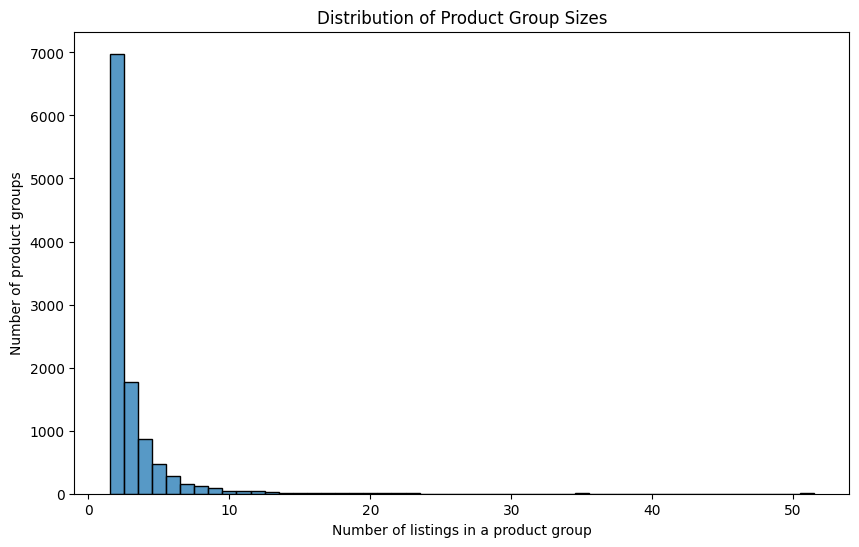

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    group_sizes,
    bins=range(1, group_sizes.max() + 2),
    discrete=True
)

plt.xlabel("Number of listings in a product group")
plt.ylabel("Number of product groups")
plt.title("Distribution of Product Group Sizes")
plt.show()

In [15]:
group_sizes = train["label_group"].value_counts()

print(group_sizes.describe())

print("\nGroup size counts:")
print("1 listing :", (group_sizes == 1).sum())
print("2 listings:", (group_sizes == 2).sum())
print("3 listings:", (group_sizes == 3).sum())
print("4 listings:", (group_sizes == 4).sum())
print("5+ listings:", (group_sizes >= 5).sum())

count    11014.000000
mean         3.109679
std          2.940827
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         51.000000
Name: count, dtype: float64

Group size counts:
1 listing : 0
2 listings: 6979
3 listings: 1779
4 listings: 862
5+ listings: 1394


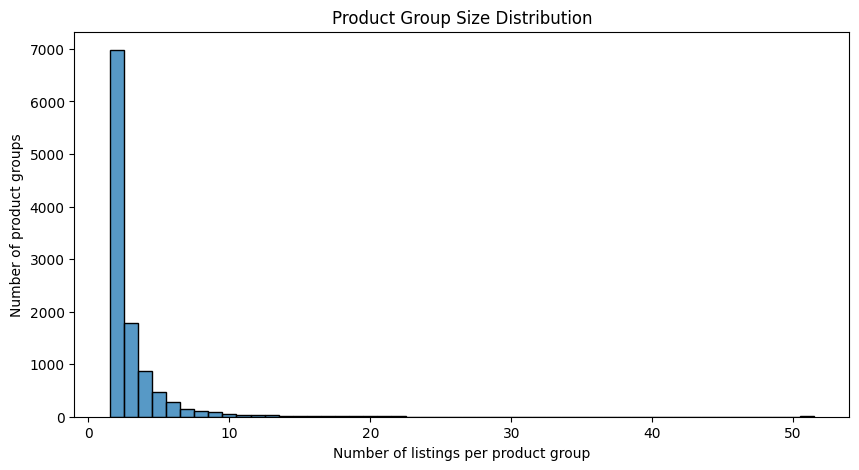

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(group_sizes, discrete=True)

plt.xlabel("Number of listings per product group")
plt.ylabel("Number of product groups")
plt.title("Product Group Size Distribution")
plt.show()

In [17]:
#title analysis
train["title_words"] = train["title"].str.split().str.len()
train["title_chars"] = train["title"].str.len()

print("TITLE STATISTICS")
print(train[["title_words", "title_chars"]].describe())

print("\nAverage words per title:", train["title_words"].mean())
print("Shortest title:", train["title_words"].min(), "words")
print("Longest title:", train["title_words"].max(), "words")



TITLE STATISTICS
        title_words   title_chars
count  34250.000000  34250.000000
mean       9.414861     56.163474
std        4.446719     25.100492
min        1.000000      5.000000
25%        6.000000     36.000000
50%        9.000000     53.000000
75%       12.000000     73.000000
max       61.000000    357.000000

Average words per title: 9.414861313868613
Shortest title: 1 words
Longest title: 61 words


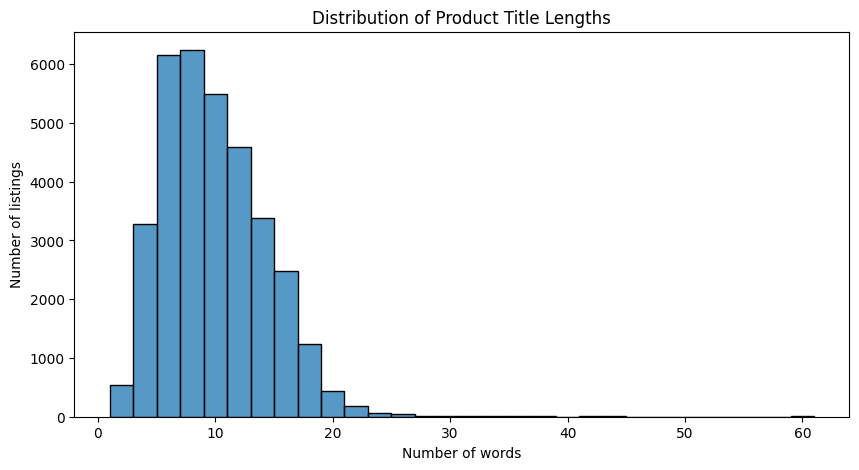

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(train["title_words"], bins=30)

plt.xlabel("Number of words")
plt.ylabel("Number of listings")
plt.title("Distribution of Product Title Lengths")
plt.show()

In [19]:
#Image/hash analysis
print("Unique images:", train["image"].nunique())
print("Duplicate image entries:", train["image"].duplicated().sum())

print("\nUnique pHashes:", train["image_phash"].nunique())
print("Duplicate pHash entries:", train["image_phash"].duplicated().sum())

Unique images: 32412
Duplicate image entries: 1838

Unique pHashes: 28735
Duplicate pHash entries: 5515


In [20]:
# How many listings share the same pHash?
phash_counts = train["image_phash"].value_counts()

print("\nMost common pHashes:")
print(phash_counts.head(10))


Most common pHashes:
image_phash
fad28daa2ad05595    26
d0c0ea37bd9acce0    20
be12e12f9ec1e198    17
f6d98134b904b56b    16
e992966d4ba49761    16
ba96cc48cc63c56b    14
84563f696135c79a    13
def6e14b4a398885    13
bb13e24edd48d02e    12
9e8966c3ad4ecc62    12
Name: count, dtype: int64


In [21]:
#Same product different listings
group = train.groupby("label_group")

# Groups with at least 2 listings
multi_groups = group.filter(lambda x: len(x) >= 2)

example_group = multi_groups["label_group"].value_counts().index[0]

print("Example product group:", example_group)

print(
    train[train["label_group"] == example_group]
    [["posting_id", "title", "image", "image_phash"]]
    .to_string(index=False)
)

Example product group: 562358068
      posting_id                                                                                        title                                image      image_phash
train_1251926547                                   VIVA Cleansing Milk, VIVA Air Mawar, VIVA Face Toner 100ml 0233d1522f95031e111d777739e9f1e9.jpg a686c86331cd3fac
 train_576940044                                                                         VIVA AIR MAWAR 100ML 05bbba6828fa60b2475581185592a6e2.jpg cc91a56a9be26cc9
train_2821917682                                                                         Viva air mawar 100ml 05bbba6828fa60b2475581185592a6e2.jpg cc91a56a9be26cc9
train_3942479788                                                                        VIVA Air Mawar 100 ml 107af60a2f111adfa929dc2b7ee01b14.jpg e699996699666499
train_2262165918  VIVA Air Mawar / Face Tonic / Milk Cleanser 100ml / 200ml [toner penyegar / susu pembersih] 107d0ee856a261b74539ea41c8a20e29.jpg 

In [24]:
#FIND GROUPS WITH MANY LISTINGS

print(
    train["label_group"]
    .value_counts()
    .head(10)
)

label_group
562358068     51
159351600     51
3113678103    51
3627744656    51
994676122     51
1141798720    51
1163569239    51
3206118280    49
1166650192    46
1733221456    46
Name: count, dtype: int64


In [25]:
#DUPLICATE TITLES
# DUPLICATE TITLES

title_counts = train["title"].value_counts()

print("Unique titles:", train["title"].nunique())
print("Duplicate title entries:", train["title"].duplicated().sum())

print("\nMost common titles:")
print(title_counts.head(10))

Unique titles: 33117
Duplicate title entries: 1133

Most common titles:
title
Koko syubbanul muslimin koko azzahir koko baju                                                          9
Baju Koko Pria Gus Azmi Syubbanul Muslimin Kombinasi Hadroh Azzahir Hilw HO187 KEMEJA KOKO PRIA BAJU    8
Monde Boromon Cookies 1 tahun+ 120gr                                                                    6
Viva Air Mawar                                                                                          6
Emina Glossy Stain                                                                                      6
100 Pcs Ikat Rambut Karet Polos Elastis Gaya Korea untuk Wanita                                         6
Shannen lipstik shanen creamy lip paint                                                                 5
Herborist Lulur Tradisional Bali 100gr                                                                  5
Avoskin Miraculous Retinol Toner                                          

In [26]:

# pHASH CONSISTENCY

phash_groups = (
    train.groupby("image_phash")["label_group"]
    .nunique()
)

print("pHashes appearing in multiple product groups:",
      (phash_groups > 1).sum())

print("Maximum product groups sharing one pHash:",
      phash_groups.max())

pHashes appearing in multiple product groups: 147
Maximum product groups sharing one pHash: 4


In [27]:
#SAME PRODUCT DIFFEREN TITLES
# TITLE VARIATION WITHIN PRODUCT GROUPS

group_title_counts = (
    train.groupby("label_group")["title"]
    .nunique()
)

print("Groups with exactly one unique title:",
      (group_title_counts == 1).sum())

print("Groups with multiple titles:",
      (group_title_counts > 1).sum())

print("Maximum different titles within one group:",
      group_title_counts.max())

Groups with exactly one unique title: 289
Groups with multiple titles: 10725
Maximum different titles within one group: 51


In [28]:
# SAME PRODUCT, DIFFERENT LISTINGS

example_groups = (
    train["label_group"]
    .value_counts()
    .loc[lambda x: x >= 3]
    .head(3)
    .index
)

for group_id in example_groups:
    print("\n" + "=" * 80)
    print("LABEL GROUP:", group_id)

    print(
        train[train["label_group"] == group_id]
        [["posting_id", "title", "image", "image_phash"]]
        .to_string(index=False)
    )


LABEL GROUP: 562358068
      posting_id                                                                                        title                                image      image_phash
train_1251926547                                   VIVA Cleansing Milk, VIVA Air Mawar, VIVA Face Toner 100ml 0233d1522f95031e111d777739e9f1e9.jpg a686c86331cd3fac
 train_576940044                                                                         VIVA AIR MAWAR 100ML 05bbba6828fa60b2475581185592a6e2.jpg cc91a56a9be26cc9
train_2821917682                                                                         Viva air mawar 100ml 05bbba6828fa60b2475581185592a6e2.jpg cc91a56a9be26cc9
train_3942479788                                                                        VIVA Air Mawar 100 ml 107af60a2f111adfa929dc2b7ee01b14.jpg e699996699666499
train_2262165918  VIVA Air Mawar / Face Tonic / Milk Cleanser 100ml / 200ml [toner penyegar / susu pembersih] 107d0ee856a261b74539ea41c8a20e29.jpg b2e9ce16c